<a href="https://colab.research.google.com/github/itsmekrish887/testrepo/blob/Unsupervised_learning/Unsupervised_customer_segmentation_sales_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RFM**

*   R(Recency) : Last time bought
*   F(Frequency) : How many times
*   M(Monetery) : How much

Link: https://clevertap.com/blog/rfm-analysis/

**Objective**


*   We would be comparing the effectiveness of three clustering in customer segmentation.


**Aim:**
*   Compare the effectiveness in creating clusters
*   Customer Segmentation based in RFM analysis








In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Online_retail_data.csv')
df.head()

,Invoice,Description,Quantity,InvoiceDate,Price,Customer ID
0,INV1,Product D,12,2023-01-01 00:00:00,63.86,C56
1,INV2,Product E,12,2023-01-01 01:00:00,75.73,C76
2,INV3,Product C,4,2023-01-01 02:00:00,17.88,C51
3,INV4,Product E,16,2023-01-01 03:00:00,41.54,C37
4,INV5,Product E,4,2023-01-01 04:00:00,42.85,C17


In [4]:
df.shape

(1000, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Invoice      1000 non-null   object 
 1   Description  1000 non-null   object 
 2   Quantity     1000 non-null   int64  
 3   InvoiceDate  1000 non-null   object 
 4   Price        1000 non-null   float64
 5   Customer ID  1000 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 47.0+ KB


Pre-processing data

In [8]:
df.isnull().sum()

,0
Invoice,0
Description,0
Quantity,0
InvoiceDate,0
Price,0
Customer ID,0


No missing values

In [10]:
df.duplicated().sum()

np.int64(0)

No duplicate values

In [11]:
df.describe()

,Quantity,Price
count,1000.000000,1000.000000
mean,9.977000,49.881190
std,5.470868,28.834394
min,1.000000,1.020000
25%,5.000000,24.027500
50%,10.000000,50.080000
75%,15.000000,75.097500
max,19.000000,99.970000


**Check**: Data errors: Negative values or zero in price/quantity

In [19]:
df[(df['Quantity']<=0) & (df['Price']<=0)]

,Invoice,Description,Quantity,InvoiceDate,Price,Customer ID


**Feature Engineering**

In [20]:
df.head(3)

,Invoice,Description,Quantity,InvoiceDate,Price,Customer ID
0,INV1,Product D,12,2023-01-01 00:00:00,63.86,C56
1,INV2,Product E,12,2023-01-01 01:00:00,75.73,C76
2,INV3,Product C,4,2023-01-01 02:00:00,17.88,C51


In [44]:
df['Total_Price'] = df['Quantity'] * df['Price']

In [45]:
df.head(3)

,Invoice,Description,Quantity,InvoiceDate,Price,Customer ID,Total Price,Total_Price
0,INV1,Product D,12,2023-01-01 00:00:00,63.86,C56,766.32,766.32
1,INV2,Product E,12,2023-01-01 01:00:00,75.73,C76,908.76,908.76
2,INV3,Product C,4,2023-01-01 02:00:00,17.88,C51,71.52,71.52


Computing Recency, Frequency and Monetery

In [71]:
#changfing datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Invoice      1000 non-null   object        
 1   Description  1000 non-null   object        
 2   Quantity     1000 non-null   int64         
 3   InvoiceDate  1000 non-null   datetime64[ns]
 4   Price        1000 non-null   float64       
 5   Customer ID  1000 non-null   object        
 6   Total Price  1000 non-null   float64       
 7   Total_Price  1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 62.6+ KB


In [73]:
df.head(1)

,Invoice,Description,Quantity,InvoiceDate,Price,Customer ID,Total Price,Total_Price
0,INV1,Product D,12,2023-01-01,63.86,C56,766.32,766.32


In [74]:
current_date = df['InvoiceDate'].max()

In [75]:
current_date

Timestamp('2023-02-11 15:00:00')

In [76]:
rfm = df.groupby('Customer ID').agg({'InvoiceDate': lambda x :(current_date - x.max()).days,
                                     'Invoice':'count',
                                     'Total Price':'sum'})


In [52]:
rfm

,InvoiceDate,Invoice,Total Price
Customer ID,,,
C1,1,9,6319.24
C10,2,14,8097.72
C100,11,13,5465.74
C11,2,8,4313.14
C12,5,6,4148.32
...,...,...,...
C95,17,5,2746.12
C96,4,11,6534.14
C97,1,10,3545.95


In [77]:
rfm.columns = ['Recency', 'Frequency', 'Monetery'] # Changing the list of column names to match the actual number of columns in the 'rfm' DataFrame. The groupby column, 'Customer ID', automatically becomes the index.

In [78]:
rfm.head()

,Recency,Frequency,Monetery
Customer ID,,,
C1,1,9,6319.24
C10,2,14,8097.72
C100,11,13,5465.74
C11,2,8,4313.14
C12,5,6,4148.32


<Axes: ylabel='Density'>

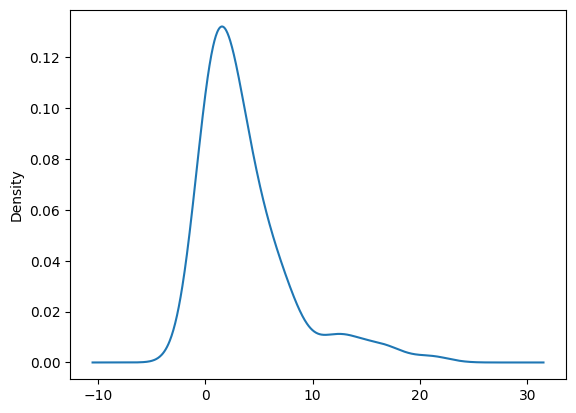

In [79]:
rfm['Recency'].plot(kind='kde') # Changed knde to kind='kde' to generate a kernel density estimate plot.

In [61]:
print(rfm['Recency'].skew())

1.918179531371328


In [80]:
#If the date is today, then it comes out as 0. Log0 is error, hence 1 added
rfm['Recency_log'] = np.log(rfm['Recency']+1)
rfm['Frequency_log'] = np.log(rfm['Frequency'])
rfm['Monetary_log'] = np.log(rfm['Monetery'])
rfm.head()

,Recency,Frequency,Monetery,Recency_log,Frequency_log,Monetary_log
Customer ID,,,,,,
C1,1,9,6319.24,0.693147,2.197225,8.751354
C10,2,14,8097.72,1.098612,2.639057,8.999338
C100,11,13,5465.74,2.484907,2.564949,8.606255
C11,2,8,4313.14,1.098612,2.079442,8.369421
C12,5,6,4148.32,1.791759,1.791759,8.330459


<Axes: ylabel='Density'>

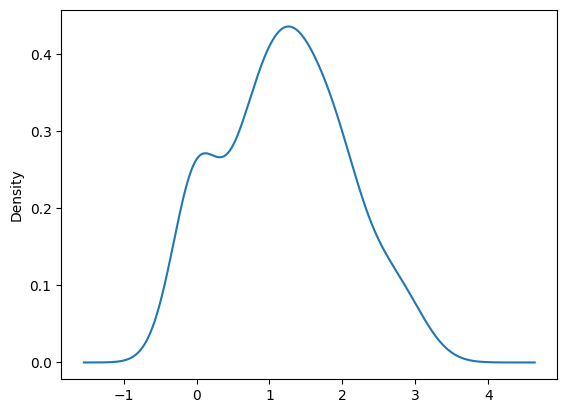

In [81]:
rfm['Recency_log'].plot(kind='kde')

In [67]:
print(rfm['Recency_log'].skew())

0.1307612276293228


In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency_log', 'Frequency_log', 'Monetary_log']])

In [83]:
rfm_scaled

array([[-0.6173607 , -0.16370139,  0.69130985],
       [-0.126774  ,  1.16229659,  1.22367705],
       [ 1.55055298,  0.93988886,  0.37981272],
       [-0.126774  , -0.51718372, -0.1286173 ],
       [ 0.71188949, -1.38055531, -0.21226189],
       [-1.45602419,  1.36935324,  0.86953404],
       [ 1.89862977, -3.46078083, -2.9277766 ],
       [-0.126774  , -0.51718372, -0.43455199],
       [ 1.20247618, -0.51718372, -0.67676885],
       [-1.45602419,  1.5630418 ,  0.48450342],
       [-0.126774  , -0.91792892, -2.00861109],
       [-0.6173607 ,  0.43853766, -0.23699052],
       [ 1.05996628, -1.38055531,  0.3324603 ],
       [ 1.73706538, -1.38055531, -0.21910387],
       [ 0.71188949,  0.6996702 ,  0.20902971],
       [-0.126774  ,  0.6996702 ,  0.3061602 ],
       [ 0.22130279, -0.51718372, -0.57911242],
       [-0.126774  , -0.16370139, -1.29513984],
       [-1.45602419,  0.6996702 ,  0.77948988],
       [-1.45602419,  0.43853766, -0.33708905],
       [ 0.71188949,  0.6996702 ,  0.591

Visualising our data

(<Figure size 1000x300 with 3 Axes>,
 array([<Axes: >, <Axes: >, <Axes: >], dtype=object))

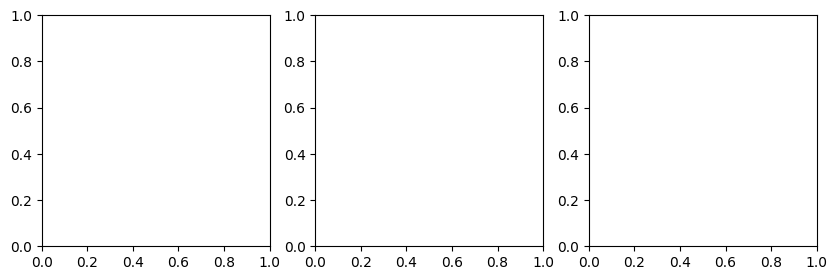

In [84]:
plt.subplots(1,3, figsize=(10,3))

<Axes: xlabel='Monetary_log', ylabel='Count'>

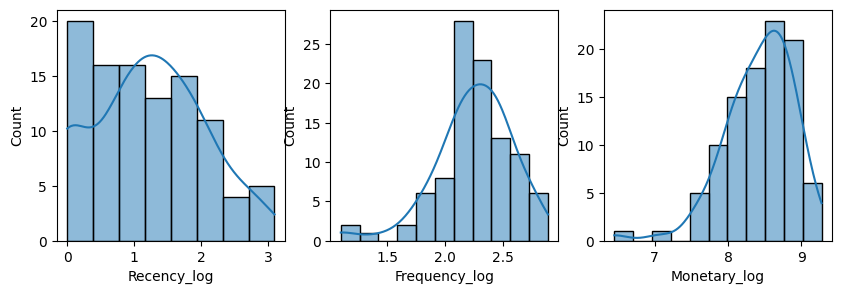

In [93]:
plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
sns.histplot(rfm['Recency_log'],kde = True)
plt.subplot(1,3,2)
sns.histplot(rfm['Frequency_log'],kde = True)
plt.subplot(1,3,3)
sns.histplot(rfm['Monetary_log'],kde = True)





**Modeling**

K-Means : Elbow Method

In [145]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#Elbow
wcss =[]

for i in range (1,11):
   kmeans = KMeans(n_clusters=i)
   kmeans.fit(rfm_scaled)
   wcss.append(kmeans.inertia_)

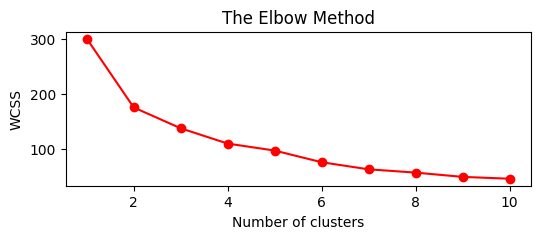

In [103]:
plt.figure(figsize=(6,2))
plt.plot(range(1,11), wcss, marker='o', color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [109]:
#Applying Kmeans with optimal k =2

kmeans_optimal = KMeans(n_clusters=2, init = 'k-means++')
kmeans_optimal.fit(rfm_scaled)

KMeans(n_clusters=2)

In [110]:
rfm['cluster'] = kmeans_optimal.labels_

In [111]:
rfm.head()

,Recency,Frequency,Monetery,Recency_log,Frequency_log,Monetary_log,cluster
Customer ID,,,,,,,
C1,1,9,6319.24,0.693147,2.197225,8.751354,0
C10,2,14,8097.72,1.098612,2.639057,8.999338,0
C100,11,13,5465.74,2.484907,2.564949,8.606255,0
C11,2,8,4313.14,1.098612,2.079442,8.369421,1
C12,5,6,4148.32,1.791759,1.791759,8.330459,1


In [146]:
silhouette_avg = silhouette_score(rfm_scaled, kmeans_optimal.labels_)
print("Silhouette Score:", silhouette_avg)


Silhouette Score: 0.3625081959919717


Text(0, 0.5, 'Frequency_log')

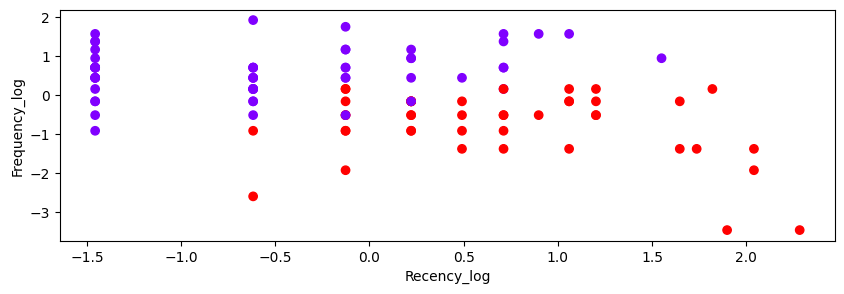

In [126]:
plt.figure(figsize=(10,3))
plt.scatter(rfm_scaled[:,0], rfm_scaled[:,1], c=kmeans_optimal.labels_, cmap='rainbow')
plt.xlabel('Recency_log')
plt.ylabel('Frequency_log')

Hierarchical clustering

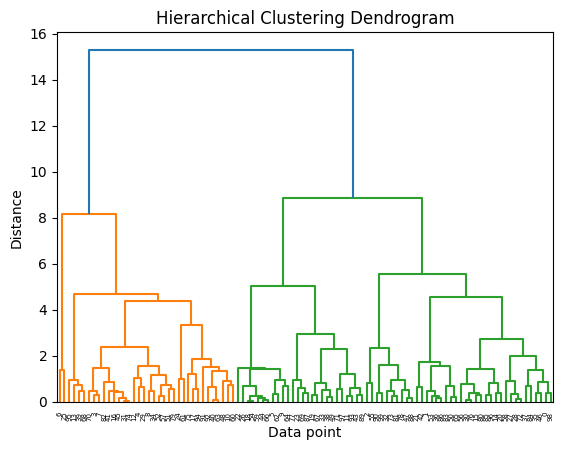

In [133]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(rfm_scaled, 'ward')
dendrogram(Z) # Plotting the dendrogram
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data point')
plt.ylabel('Distance')
plt.show()

In [134]:
from sklearn.cluster import DBSCAN

In [135]:
rfm['heir_cluster'] = fcluster(Z, 2, criterion = 'maxclust')

In [147]:
silhouette_avg_heir = silhouette_score(rfm_scaled, rfm['heir_cluster'])
print("Silhouette Score:", silhouette_avg)

Silhouette Score: 0.3625081959919717


DBSCAN

In [150]:
dbscan = DBSCAN(eps=0.5, min_samples=6)
dbscan.fit(rfm_scaled)

DBSCAN(min_samples=6)

In [152]:
rfm['dbscan_cluster'] = dbscan.fit_predict(rfm_scaled)

In [153]:
rfm['dbscan_cluster'].unique()

array([-1,  0,  2,  1])

In [162]:
#We have to remove the cluster with -1, it is noise. No data should be coming in nagative
silhouette_avg_dbscan = silhouette_score(rfm_scaled[rfm['dbscan_cluster'] != -1], rfm['dbscan_cluster'][rfm['dbscan_cluster'] != -1])
print("silhouette_avg_dbscan", silhouette_avg_dbscan)

silhouette_avg_dbscan 0.6829250993998572


In [163]:
print("All SIlhouette Scores:")
print("K-Means:", silhouette_avg)
print("Hierarchical:", silhouette_avg_heir)
print("DBSCAN:", silhouette_avg_dbscan)

All SIlhouette Scores:
K-Means: 0.3625081959919717
Hierarchical: 0.3416192286034576
DBSCAN: 0.6829250993998572
